# Distributions - Basic Discrete and Continuous

This notebook demonstrates the basic distribution API in probjax.

All distributions follow a consistent interface:
- `logpdf(x)` - log probability density/mass function
- `rvs(key, shape)` - random variates
- `mean`, `var`, `std` - moments
- `sample(key)` - single sample

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import probjax.stats as stats

key = jax.random.PRNGKey(0)

## Continuous Distributions

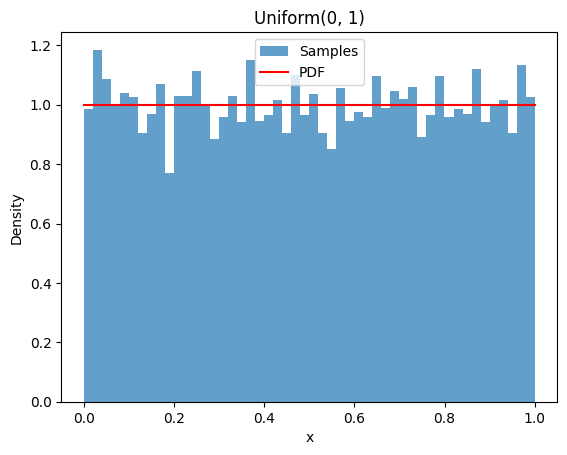

Mean: 0.500, Var: 0.083


In [3]:
# Uniform distribution
p = stats.uniform(low=0., high=1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

# Plot PDF
xs = jnp.linspace(0, 1, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Uniform(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean():.3f}, Var: {p.var():.3f}")

In [ ]:
# Normal distribution
p = stats.norm(loc=0., scale=1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(-4, 4, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Normal(0, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Gamma distribution
p = stats.gamma(a=2., scale=1.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 8, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gamma(2, 1)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Beta distribution
p = stats.beta(a=2., b=5.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 1, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Beta(2, 5)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Exponential distribution
p = stats.expon(scale=2.)

samples = p.rvs(key, shape=(10000,))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Samples')

xs = jnp.linspace(0, 10, 100)
plt.plot(xs, jnp.exp(p.logpdf(xs)), 'r-', label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Exponential(2)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

## Discrete Distributions

In [ ]:
# Bernoulli distribution
p = stats.bernoulli(probs=0.3)

samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Bernoulli(0.3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Binomial distribution
p = stats.binomial(n=20, p=0.3)

samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Binomial(20, 0.3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Poisson distribution
p = stats.poisson(mu=3.)

samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Poisson(3)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Geometric distribution
p = stats.geometric(p=0.5)

samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support[:15], counts[:15]/10000, alpha=0.7, label='Empirical')
plt.plot(support[:15], jnp.exp(p.logpmf(support[:15])), 'ro', label='PMF')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Geometric(0.5)')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

In [ ]:
# Categorical distribution
p = stats.categorical(probs=jnp.array([0.1, 0.2, 0.3, 0.4]))

samples = p.rvs(key, shape=(10000,))
support, counts = jnp.unique(samples, return_counts=True)

plt.bar(support, counts/10000, alpha=0.7, label='Empirical')
plt.plot(support, jnp.exp(p.logpmf(support)), 'ro', label='PMF')
plt.xlabel('Category')
plt.ylabel('Probability')
plt.title('Categorical([0.1, 0.2, 0.3, 0.4])')
plt.legend()
plt.show()

print(f"Mean: {p.mean:.3f}, Var: {p.var:.3f}")

## Multivariate Distributions

In [ ]:
# Multivariate Normal
mean = jnp.array([0., 0.])
cov = jnp.array([[1., 0.5], [0.5, 1.]])
p = stats.multivariate_normal(mean=mean, cov=cov)

samples = p.rvs(key, shape=(5000,))

plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multivariate Normal([0, 0], [[1, 0.5], [0.5, 1]])')
plt.axis('equal')
plt.show()

print(f"Mean: {p.mean}")
print(f"Cov:\n{p.cov}")

In [ ]:
# Dirichlet distribution
alpha = jnp.array([2., 3., 5.])
p = stats.dirichlet(alpha=alpha)

samples = p.rvs(key, shape=(5000,))

# Plot on simplex
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], alpha=0.3, s=5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Dirichlet([2, 3, 5])')
plt.show()

print(f"Mean: {p.mean}")

## Summary

All distributions in probjax share a consistent API:

- **Initialization**: Create with parameters (e.g., `stats.norm(loc=0, scale=1)`)
- **Log probability**: `logpdf(x)` for continuous, `logpmf(x)` for discrete
- **Sampling**: `rvs(key, shape)` for multiple samples, `sample(key)` for single
- **Moments**: Access `mean`, `var`, `std` as properties

This unified interface makes it easy to swap distributions in models and algorithms.